# Pteropods Model : acidity implementative from Bednarsek 


In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

from seapopym.configuration.acidity import (
    ForcingParameter,
)
from seapopym.configuration.acidity_bed import (
    AcidityBedConfiguration,
    FunctionalGroupParameter,
    FunctionalGroupUnit,
    FunctionalTypeParameter,
)
from seapopym.configuration.no_transport import (
    ForcingUnit,
    MigratoryTypeParameter,
)
from seapopym.model import AcidityBedModel
from seapopym.standard.coordinate_authority import (
    create_latitude_coordinate,
    create_layer_coordinate,
    create_longitude_coordinate,
    create_time_coordinate,
)
from seapopym.standard.units import StandardUnitsLabels

## Generating data for the 1D simulation at station PAPA

Let's generate data for the 1D simulation, using temperature, NPP and aragonite fields from PAPA station.


In [3]:
data_path = "/home/salbernhe/workspace/pteropod/data/papa_forcings/"
aragonite_file = data_path + "daily_interp_aragonite_papa_1998_2020.nc"
temperature_file = data_path + "daily_temp_papa_1998_2020.nc"
npp_file = data_path + "daily_pp_papa_1998_2020.nc"
npp_behrenfeld_file = data_path + "daily_BEHRENFELD_papa_1998_2020.nc"

data_aragonite = xr.open_dataset(aragonite_file)
data_temperature = xr.open_dataset(temperature_file)
data_npp = xr.open_dataset(npp_file)

infos_forcings = [
    {
        "Variable": "Aragonite",
        "Shape": data_aragonite["omega_ar"].shape,
        "Unique values": len(np.unique(data_aragonite["omega_ar"])),
        "NaNs": int(np.isnan(data_aragonite["omega_ar"]).sum()),
    },
    {
        "Variable": "Temperature",
        "Shape": data_temperature["T"].shape,
        "Unique values": len(np.unique(data_temperature["T"])),
        "NaNs": int(np.isnan(data_temperature["T"]).sum()),
    },
    {
        "Variable": "NPP",
        "Shape": data_npp["npp"].shape,
        "Unique values": len(np.unique(data_npp["npp"])),
        "NaNs": int(np.isnan(data_npp["npp"]).sum()),
    },
]

#print(infos_forcings)


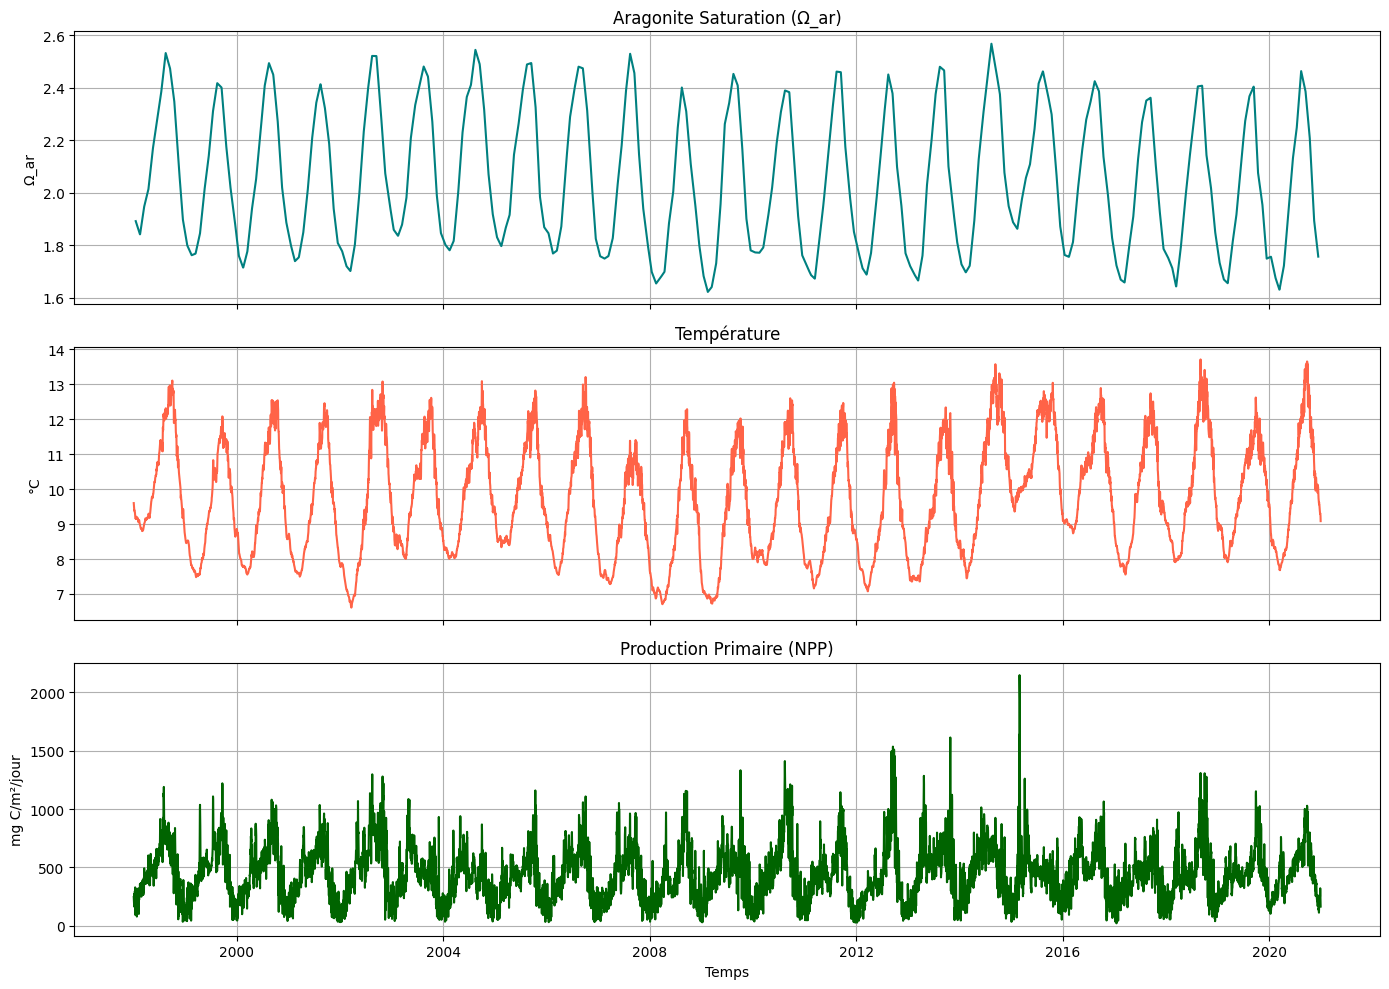

In [4]:
# Création de la figure
fig, axs = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# Tracé Aragonite
axs[0].plot(data_aragonite["time"], data_aragonite["omega_ar"].squeeze(), color="teal")
axs[0].set_title("Aragonite Saturation (Ω_ar)")
axs[0].set_ylabel("Ω_ar")
axs[0].grid(True)

# Tracé Température
axs[1].plot(data_temperature["time"], data_temperature["T"].squeeze(), color="tomato")
axs[1].set_title("Température")
axs[1].set_ylabel("°C")
axs[1].grid(True)

# Tracé NPP
axs[2].plot(data_npp["time"], data_npp["npp"].squeeze(), color="darkgreen")
axs[2].set_title("Production Primaire (NPP)")
axs[2].set_ylabel("mg C/m²/jour")
axs[2].set_xlabel("Temps")
axs[2].grid(True)

plt.tight_layout()
plt.show()


In [5]:
temperature = xr.DataArray(
    dims=["T", "Y", "X", "Z"],
    coords={
        "T": create_time_coordinate(pd.to_datetime(data_temperature["time"].values)),
        "Y": create_latitude_coordinate([0]),
        "X": create_longitude_coordinate([0]),
        "Z": create_layer_coordinate([0]),
    },
    attrs={"units": StandardUnitsLabels.temperature},
    data=data_temperature["T"].values[:, np.newaxis, np.newaxis, np.newaxis],
)

acidity = xr.DataArray(
    dims=["T", "Y", "X", "Z"],
    coords={
        "T": create_time_coordinate(pd.to_datetime(data_aragonite["time"].values)),
        "Y": create_latitude_coordinate([0]),
        "X": create_longitude_coordinate([0]),
        "Z": create_layer_coordinate([0]),
    },
    attrs={"units": StandardUnitsLabels.acidity},
    data=data_aragonite["omega_ar"].values[:, np.newaxis, np.newaxis, np.newaxis],
)

primary_production = xr.DataArray(
    dims=["T", "Y", "X"],
    coords={
        "T": create_time_coordinate(pd.to_datetime(data_npp["time"].values)),
        "Y": create_latitude_coordinate([0]),
        "X": create_longitude_coordinate([0]),
    },
    attrs={"units": "mg/m2/day"},
    data=data_npp["npp"].values[:, np.newaxis, np.newaxis],
)


dataset = xr.Dataset({"temperature": temperature, "primary_production": primary_production, "acidity": acidity})


## Initialize the model

First we set up the model parameters. We will define a single functional group with the commonly used parameters for the zooplankton in Seapodym LMTL.


In [6]:
f_groups = FunctionalGroupParameter(
    functional_group=[
        FunctionalGroupUnit(
            name="Pteropod",
            energy_transfert=0.1668,
            migratory_type=MigratoryTypeParameter(day_layer=0, night_layer=0),
            functional_type=FunctionalTypeParameter(
                lambda_0=-19.4,  # Bed et al.
                gamma_lambda_temperature=11.5,  # Bed et al.
                gamma_lambda_acidity=-32.7,  # Bed et al.
                survival_rate_0=13.49,  # Bed et al.
                gamma_survival_rate_temperature=-2.475,  # Bed et al.
                gamma_survival_rate_acidity=10.10,  # Bed et al.
                tr_0=20.54,  # Alex
                gamma_tr=-0.24845,  # Alex
            ),
        )
    ]
)

p_param = ForcingParameter(
    temperature=ForcingUnit(forcing=dataset["temperature"]),
    primary_production=ForcingUnit(forcing=dataset["primary_production"]),
    acidity=ForcingUnit(forcing=dataset["acidity"]),
)

parameters = AcidityBedConfiguration(forcing=p_param, functional_group=f_groups)


primary_production unit is milligram / day / meter ** 2, it will be converted to kilogram / day / meter ** 2.
primary_production unit is milligram / day / meter ** 2, it will be converted to kilogram / day / meter ** 2.


## Run the model


In [7]:
with AcidityBedModel.from_configuration(configuration=parameters) as bednarsek_model:
    bednarsek_model.run()
    display(bednarsek_model.state)
    biomass = bednarsek_model.state["biomass"]
    state = bednarsek_model.state.copy()

<xarray.Dataset> Size: 983kB
Dimensions:                          (functional_group: 1, T: 8395, Y: 1, X: 1,
                                      cohort: 21, Z: 1)
Coordinates:
  * functional_group                 (functional_group) int64 8B 0
  * T                                (T) datetime64[ns] 67kB 1998-01-01T12:00...
  * Y                                (Y) int64 8B 0
  * X                                (X) int64 8B 0
  * cohort                           (cohort) int64 168B 0 1 2 3 ... 17 18 19 20
  * Z                                (Z) int64 8B 0
Data variables: (12/35)
    biomass                          (functional_group, T, Y, X) float64 67kB ...
    recruited                        (functional_group, T, Y, X) float64 67kB ...
    mortality_field                  (functional_group, T, Y, X) float64 67kB ...
    survival_rate                    (functional_group, T, Y, X) float64 67kB ...
    mask_temperature                 (functional_group, T, Y, X, cohort) bool 176kB ...
    min_temperature                  (functional_group, cohort) float64 168B ...
    ...                               ...
    max_timestep                     (functional_group, cohort) float64 168B ...
    mean_timestep                    (functional_group, cohort) float64 168B ...
    timestep                         float64 8B 1.0
    angle_horizon_sun                float64 8B 0.0
    compute_initial_conditions       bool 1B False
    compute_preproduction            bool 1B False

## Plotting the results

### The biomass evolution over time


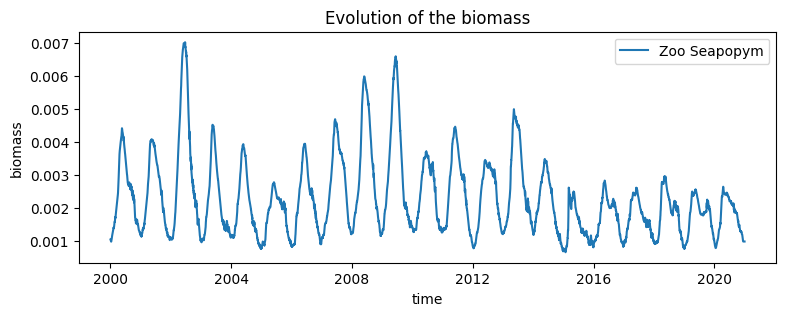

In [8]:
plt.figure(figsize=(9, 3))
biomass.sel(T=slice("2000", None)).mean(["Y", "X"]).plot(label="Zoo Seapopym", x="T", hue="functional_group")
plt.legend()
plt.title("Evolution of the biomass")
plt.show()


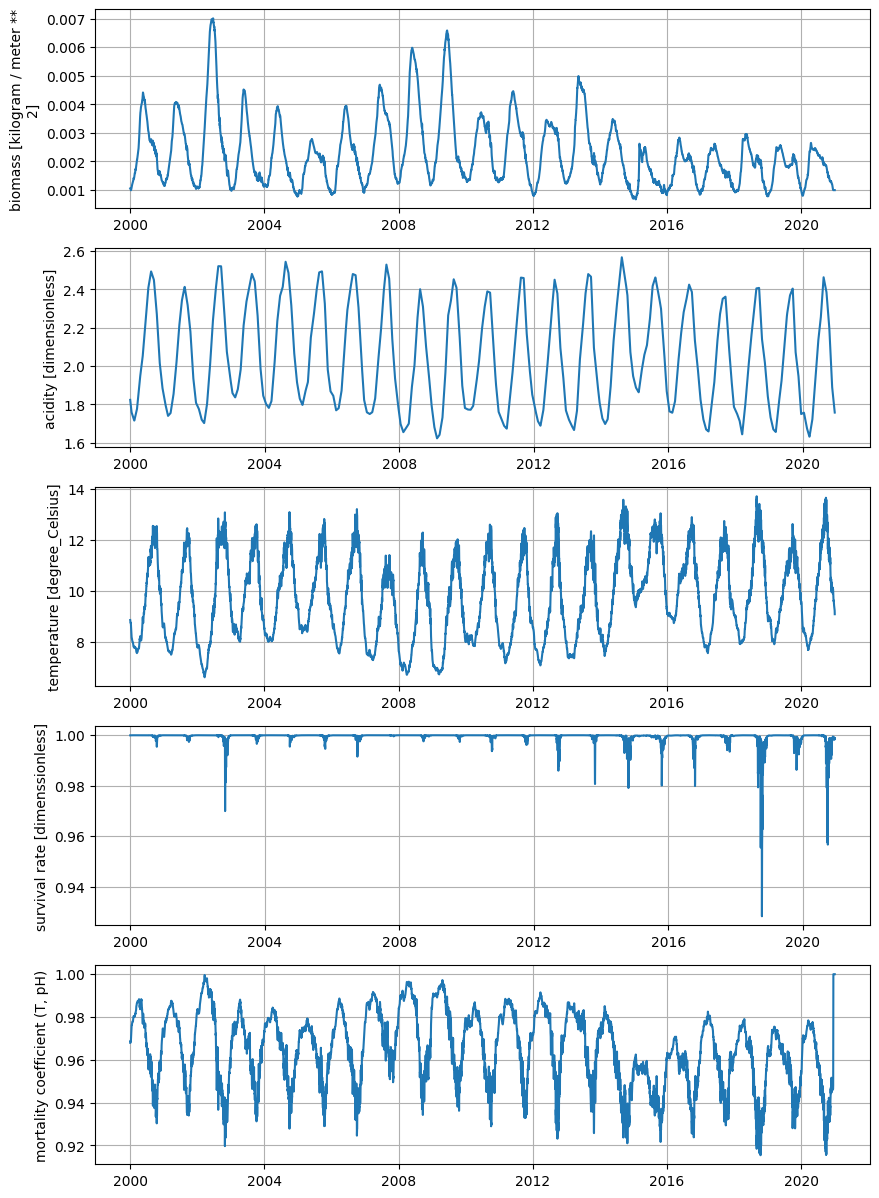

In [9]:
fig, axes = plt.subplots(5, 1, figsize=(10, 15))
state.sel(T=slice("2000", None)).biomass.squeeze().plot.line(x="T", hue="functional_group", ax=axes[0])
state.sel(T=slice("2000", None)).acidity.plot(ax=axes[1])
state.sel(T=slice("2000", None)).temperature.plot(ax=axes[2])
state.sel(T=slice("2000", None)).survival_rate.plot(ax=axes[3])
state.sel(T=slice("2000", None)).mortality_field.plot(ax=axes[4])

for ax in axes:
    ax.grid()
    ax.set_xlabel("")
    ax.set_title("")


# Comparaison avec les données de ptéropodes de la station PAPA

<xarray.DataArray 'time' (time: 219)> Size: 2kB
array(['1998-01-19T00:00:00.000000000', '1998-01-20T00:00:00.000000000',
       '1998-02-21T00:00:00.000000000', ..., '2020-08-14T00:00:00.000000000',
       '2020-08-30T00:00:00.000000000', '2020-08-31T00:00:00.000000000'],
      shape=(219,), dtype='datetime64[ns]')
Coordinates:
  * time     (time) datetime64[ns] 2kB 1998-01-19 1998-01-20 ... 2020-08-31
Attributes:
    standard_name:  time
    long_name:      time
    axis:           T


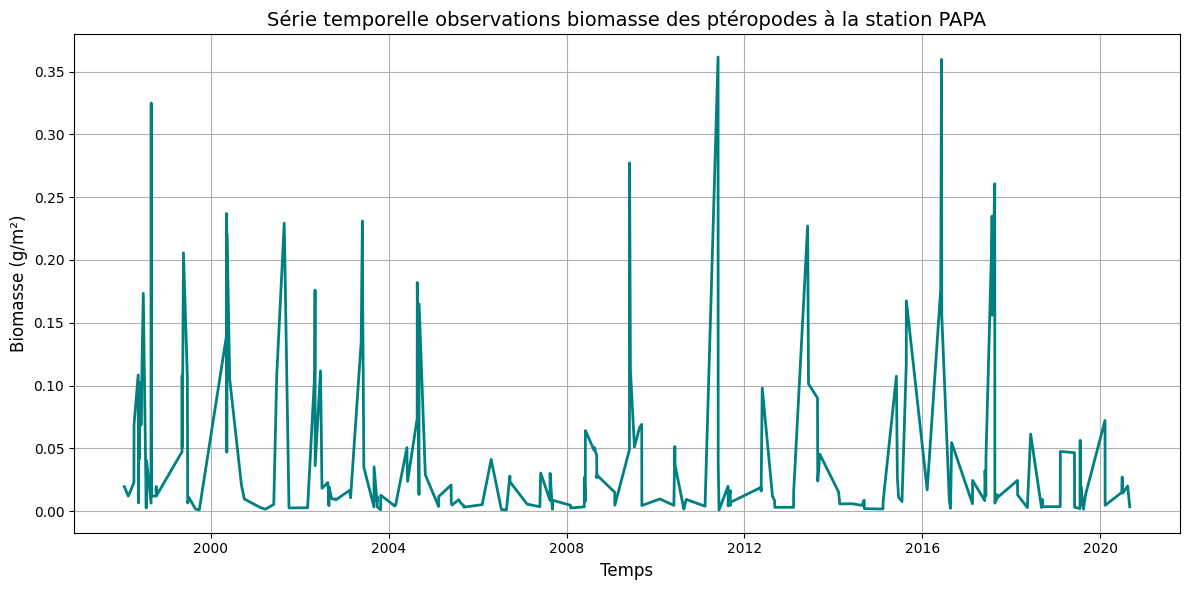

: 

In [ ]:
pteropod_file = "/home/salbernhe/workspace/pteropod/data/pteropod_data/time_serie_pter_papa_1998_2020_clean_k_075.nc"

data_pteropod = xr.open_dataset(pteropod_file)

# Tracé de la figure
plt.figure(figsize=(12, 6))
plt.plot(data_pteropod["time"], data_pteropod["pteropod_biomass_gm2"], color="teal", linewidth=2)
plt.title("Série temporelle observations biomasse des ptéropodes à la station PAPA", fontsize=14)
plt.xlabel("Temps", fontsize=12)
plt.ylabel("Biomasse (g/m²)", fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.show()


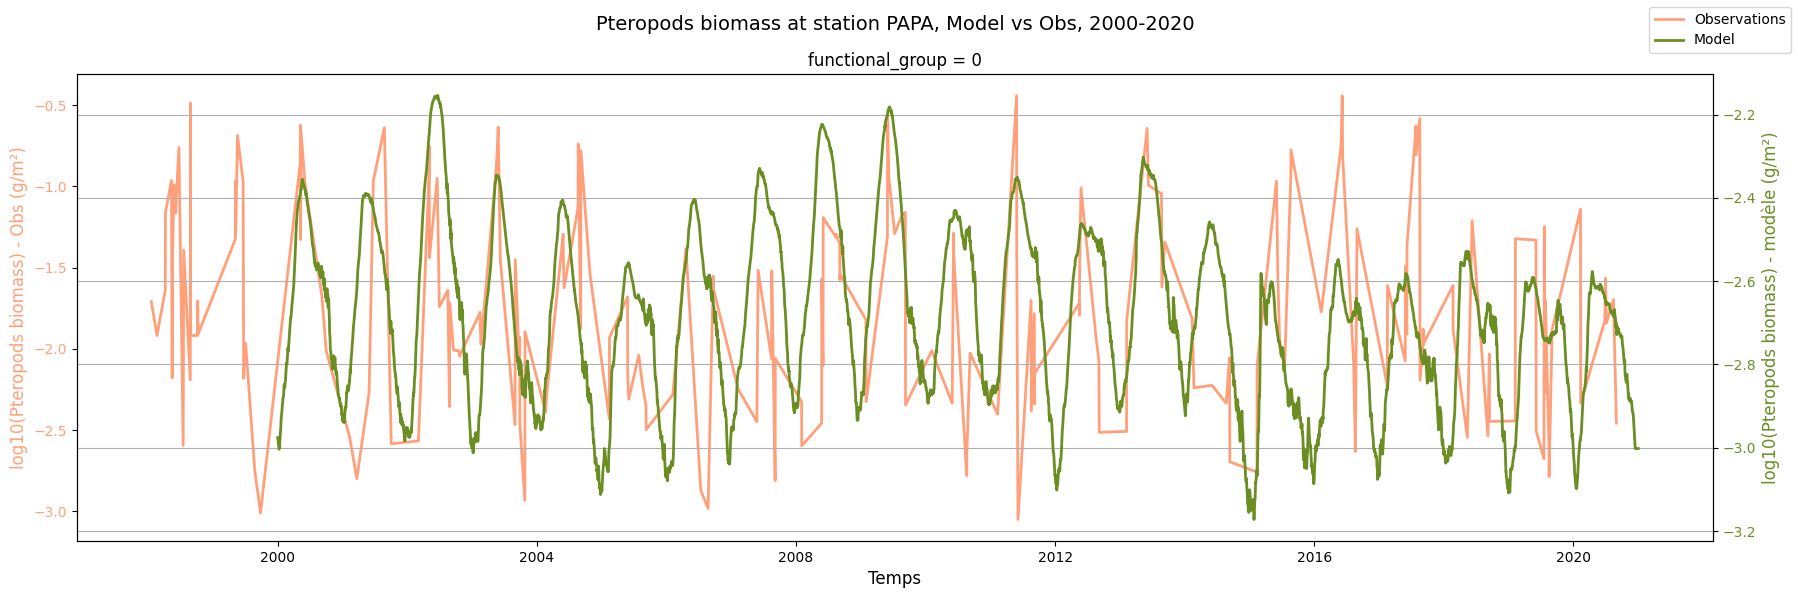

In [10]:
# Préparer les données du modèle
model_biomass = biomass.sel(T=slice("2000", None)).mean(["Y", "X"])

# Tracé avec deux axes Y
fig, ax1 = plt.subplots(figsize=(18, 6))

# Axe Y principal : ptéropodes
ax1.plot(
    data_pteropod["time"],
    np.log10(data_pteropod["pteropod_biomass_gm2"]),
    color="#FFA07A",
    linewidth=2,
    label="Observations",
)
ax1.set_xlabel("Temps", fontsize=12)
ax1.set_ylabel("log10(Pteropods biomass) - Obs (g/m²)", color="#FFA07A", fontsize=12)
ax1.tick_params(axis="y", labelcolor="#FFA07A")

# Axe Y secondaire : modèle
ax2 = ax1.twinx()
np.log10(model_biomass).plot(
    ax=ax2,
    x="T",
    label="Model",
    color="olivedrab",
    linewidth=2,
)
ax2.set_ylabel("log10(Pteropods biomass) - modèle (g/m²)", color="olivedrab", fontsize=12)
ax2.tick_params(axis="y", labelcolor="olivedrab")


# Mise en forme
fig.suptitle("Pteropods biomass at station PAPA, Model vs Obs, 2000-2020", fontsize=14)
fig.legend()

fig.tight_layout()
plt.grid(True)
plt.show()
